In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
import warnings, random
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

d:\IoT_Precision_Agriculture\IOT_VENV\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda


In [2]:
df = pd.read_csv('../Dataset/processed/final_dataset_preprocessed_v2.csv')

# Three columns have ranges in the millions — compress before scaling
# log1p is safe: handles 0s, preserves order
for col in ['water_stress', 'combined_stress', 'temp_humidity_index']:
    df[col] = np.log1p(df[col])
    print(f"log1p({col}):  min={df[col].min():.3f}  max={df[col].max():.3f}")

print(f"\nShape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Infs : {np.isinf(df.select_dtypes('number')).sum().sum()}")

log1p(water_stress):  min=0.150  max=14.012
log1p(combined_stress):  min=13.987  max=15.116
log1p(temp_humidity_index):  min=0.000  max=7.516

Shape: (9129, 41)
Nulls: 0
Infs : 0


In [3]:
# NEVER shuffle before splitting time-series data
# Order: train (70%) → val (15%) → test (15%)

FEATURE_COLS = [c for c in df.columns if c != 'target']
TARGET_COL   = 'target'

X = df[FEATURE_COLS].values   # (9132, 29)
y = df[TARGET_COL].values     # (9132,)

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],       y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f"Train : {X_train.shape}  |  stressed={y_train.mean():.2%}")
print(f"Val   : {X_val.shape}    |  stressed={y_val.mean():.2%}")
print(f"Test  : {X_test.shape}   |  stressed={y_test.mean():.2%}")

Train : (6390, 40)  |  stressed=54.62%
Val   : (1369, 40)    |  stressed=55.59%
Test  : (1370, 40)   |  stressed=80.22%


In [4]:
import joblib

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')

print("StandardScaler fit on train only — no leakage")
print(f"Train mean (should be ~0): {X_train_sc.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_sc.std():.4f}")

StandardScaler fit on train only — no leakage
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


In [5]:
def make_sequences(X, y, time_steps=7):
    """
    Converts (n_samples, n_features) → (n_sequences, time_steps, n_features)
    Label = target at the last timestep of each window.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i : i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

TIME_STEPS = 7

X_train_seq, y_train_seq = make_sequences(X_train_sc, y_train, TIME_STEPS)
X_val_seq,   y_val_seq   = make_sequences(X_val_sc,   y_val,   TIME_STEPS)
X_test_seq,  y_test_seq  = make_sequences(X_test_sc,  y_test,  TIME_STEPS)

print(f"X_train_seq : {X_train_seq.shape}  →  [samples, time_steps, features]")
print(f"X_val_seq   : {X_val_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")

X_train_seq : (6383, 7, 40)  →  [samples, time_steps, features]
X_val_seq   : (1362, 7, 40)
X_test_seq  : (1363, 7, 40)


In [6]:
class FarmDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(FarmDataset(X_train_seq, y_train_seq),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FarmDataset(X_val_seq,   y_val_seq),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(FarmDataset(X_test_seq,  y_test_seq),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Verify one batch shape
xb, yb = next(iter(train_loader))
print(f"\nSample batch — X: {xb.shape}  y: {yb.shape}")

Train batches : 100
Val   batches : 22
Test  batches : 22

Sample batch — X: torch.Size([64, 7, 40])  y: torch.Size([64])


In [7]:
class FarmLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,
            dropout      = dropout if num_layers > 1 else 0,
            bidirectional= bidirectional,
        )
        lstm_out_size = hidden_size * 2 if bidirectional else hidden_size

        self.head = nn.Sequential(
            nn.LayerNorm(lstm_out_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1),          # raw logit — BCEWithLogitsLoss handles sigmoid
        )

    def forward(self, x):
        out, _ = self.lstm(x)          # out: (batch, time_steps, hidden)
        last    = out[:, -1, :]        # take last timestep
        return self.head(last).squeeze(1)

INPUT_SIZE  = X_train_seq.shape[2]    # 29 features
model = FarmLSTM(input_size=INPUT_SIZE, hidden_size=128,
                 num_layers=2, dropout=0.3).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

FarmLSTM(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.15, inplace=False)
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 227,713


In [8]:
# pos_weight < 1 because class 1 is majority (5350 vs 3782)
# BCEWithLogitsLoss with pos_weight handles mild imbalance cleanly
pos_weight = torch.tensor([y_train_seq.sum() / (len(y_train_seq) - y_train_seq.sum())],
                            dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

print(f"pos_weight       : {pos_weight.item():.4f}")
print(f"Loss             : BCEWithLogitsLoss")
print(f"Optimizer        : Adam  lr=1e-3  wd=1e-5")
print(f"Scheduler        : ReduceLROnPlateau  patience=5")

pos_weight       : 1.2064
Loss             : BCEWithLogitsLoss
Optimizer        : Adam  lr=1e-3  wd=1e-5
Scheduler        : ReduceLROnPlateau  patience=5


In [9]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
        preds       = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == yb.long()).sum().item()
        total      += len(xb)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            loss    = criterion(logits, yb)
            total_loss += loss.item() * len(xb)
            probs   = torch.sigmoid(logits)
            preds   = (probs >= 0.5).long()
            correct += (preds == yb.long()).sum().item()
            total   += len(xb)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, correct / total, auc


EPOCHS      = 50
best_val_loss = float('inf')
history     = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_auc':[]}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc           = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        tag = '  ← saved'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"train_loss={tr_loss:.4f}  acc={tr_acc:.4f} | "
              f"val_loss={val_loss:.4f}  acc={val_acc:.4f}  auc={val_auc:.4f}{tag}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch   1/50 | train_loss=0.1707  acc=0.9464 | val_loss=0.3806  acc=0.8972  auc=0.9812  ← saved
Epoch   5/50 | train_loss=0.0836  acc=0.9663 | val_loss=0.3286  acc=0.9310  auc=0.9807
Epoch  10/50 | train_loss=0.0777  acc=0.9690 | val_loss=0.8489  acc=0.8620  auc=0.9217
Epoch  15/50 | train_loss=0.0651  acc=0.9738 | val_loss=0.6784  acc=0.8943  auc=0.9494
Epoch  20/50 | train_loss=0.0629  acc=0.9748 | val_loss=0.6501  acc=0.8994  auc=0.9612
Epoch  25/50 | train_loss=0.0537  acc=0.9798 | val_loss=0.6441  acc=0.9001  auc=0.9620
Epoch  30/50 | train_loss=0.0521  acc=0.9778 | val_loss=0.6933  acc=0.8921  auc=0.9591
Epoch  35/50 | train_loss=0.0493  acc=0.9795 | val_loss=0.7644  acc=0.8869  auc=0.9575
Epoch  40/50 | train_loss=0.0470  acc=0.9804 | val_loss=0.7993  acc=0.8847  auc=0.9553
Epoch  45/50 | train_loss=0.0472  acc=0.9806 | val_loss=0.8309  acc=0.8847  auc=0.9540
Epoch  50/50 | train_loss=0.0459  acc=0.9814 | val_loss=0.8349  acc=0.8847  auc=0.9541

Best val loss: 0.2543


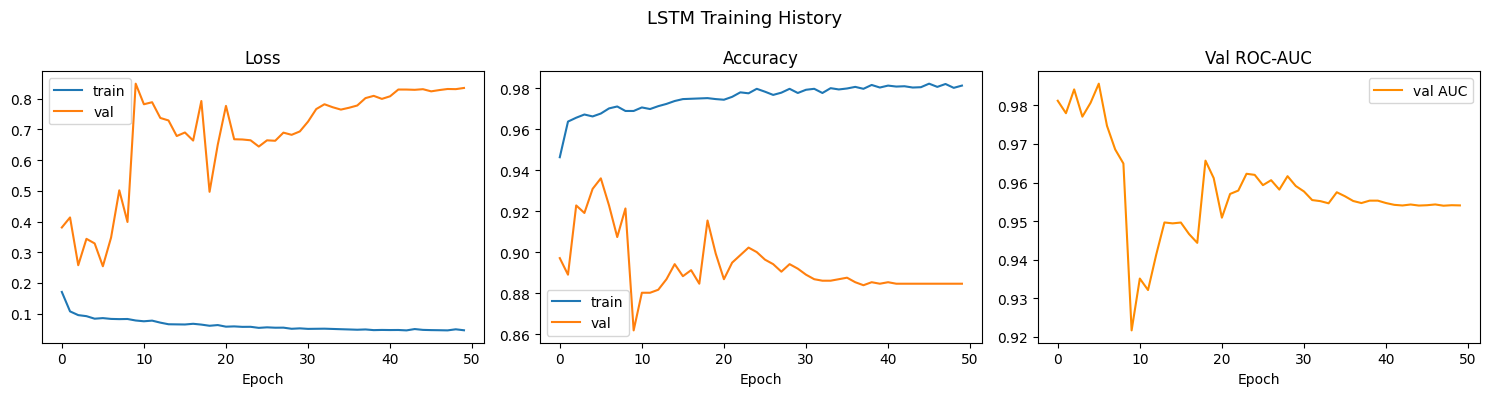

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['val_auc'], color='darkorange', label='val AUC')
axes[2].set_title('Val ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('LSTM Training History', fontsize=13)
plt.tight_layout()
plt.show()

Validate on test

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb       = xb.to(DEVICE)
        logits   = model(xb)
        probs    = torch.sigmoid(logits).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(yb.numpy().astype(int))

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['Not stressed', 'Stressed']))
print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")

TEST SET RESULTS
              precision    recall  f1-score   support

Not stressed       0.46      0.76      0.58       271
    Stressed       0.93      0.78      0.85      1092

    accuracy                           0.78      1363
   macro avg       0.70      0.77      0.71      1363
weighted avg       0.84      0.78      0.79      1363

ROC-AUC : 0.8518


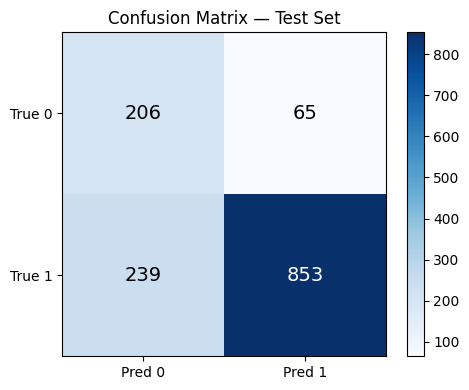

In [12]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1'])
ax.set_yticklabels(['True 0', 'True 1'])
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

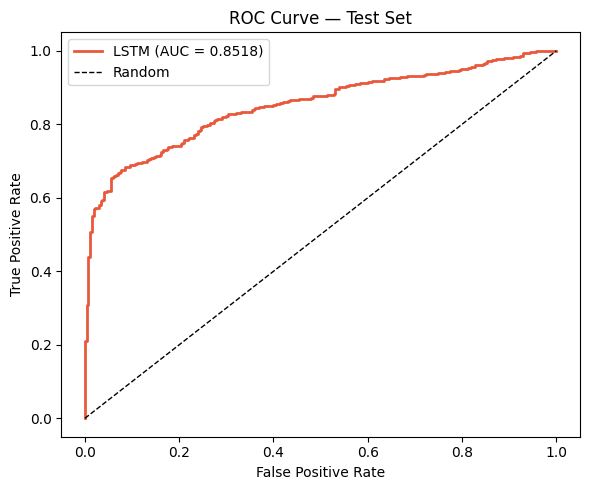

In [13]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#E8593C', lw=2, label=f'LSTM (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Default threshold=0.5 isn't always optimal
# Find threshold that maximises F1 on validation set

val_probs, val_labels = [], []
model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        logits = model(xb.to(DEVICE))
        val_probs.extend(torch.sigmoid(logits).cpu().numpy())
        val_labels.extend(yb.numpy())

val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

thresholds = np.arange(0.2, 0.8, 0.01)
f1_scores  = [f1_score(val_labels, (val_probs >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"Best threshold (by val F1) : {best_thresh:.2f}")
print(f"Val F1 at best threshold   : {max(f1_scores):.4f}")
print(f"Val F1 at 0.50             : {f1_score(val_labels, (val_probs>=0.5).astype(int)):.4f}")

# Apply best threshold to test
preds_opt = (all_probs >= best_thresh).astype(int)
print(f"\nTest results at threshold={best_thresh:.2f}:")
print(classification_report(all_labels, preds_opt,
                             target_names=['Not stressed', 'Stressed']))

Best threshold (by val F1) : 0.44
Val F1 at best threshold   : 0.9465
Val F1 at 0.50             : 0.9453

Test results at threshold=0.44:
              precision    recall  f1-score   support

Not stressed       0.47      0.74      0.58       271
    Stressed       0.93      0.80      0.86      1092

    accuracy                           0.79      1363
   macro avg       0.70      0.77      0.72      1363
weighted avg       0.84      0.79      0.80      1363



In [15]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'input_size'       : INPUT_SIZE,
    'hidden_size'      : 128,
    'num_layers'       : 2,
    'dropout'          : 0.3,
    'time_steps'       : TIME_STEPS,
    'feature_cols'     : FEATURE_COLS,
    'best_threshold'   : float(best_thresh),
    'best_val_loss'    : best_val_loss,
}, 'lstm_farm_final.pt')

import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Saved:")
print("  lstm_farm_final.pt  — full model checkpoint + metadata")
print("  scaler.pkl          — StandardScaler (needed for inference)")
print(f"\nModel expects:")
print(f"  Input shape : [batch, {TIME_STEPS}, {INPUT_SIZE}]")
print(f"  Features    : {FEATURE_COLS}")

Saved:
  lstm_farm_final.pt  — full model checkpoint + metadata
  scaler.pkl          — StandardScaler (needed for inference)

Model expects:
  Input shape : [batch, 7, 40]
  Features    : ['time_index', 'temperature', 'humidity', 'solar_radiation', 'rainfall_mm', 'water_level', 'N', 'P', 'K', 'npk_sum', 'temp_humidity_index', 'water_stress', 'fan_active', 'irrigation_active', 'irrigation_events', 'NDVI_index', 'yield_per_day', 'climate_score', 'water_efficiency', 'ndvi_health_index', 'input_intensity', 'heat_stress', 'env_index', 'combined_stress', 'fungal_risk', 'ndvi_env', 'day_of_week', 'month', 'temp_lag3', 'humidity_lag3', 'temp_lag1', 'humidity_lag1', 'temp_lag2', 'humidity_lag2', 'temp_rolling3_mean', 'temp_rolling3_std', 'hum_rolling3_mean', 'temp_delta', 'humidity_delta', 'drought_index']
